# TP1 PROCESAMIENTO DEL HABLA: webscrapping

**Crea una copia de este notebook en tu google colab**

**Renombra el notebook con el siguiente formato APELLIDO_NOMBRE_PH_TP1.ipynb**

**Amaya Francisco Gastón.**


* Resolver las consignas comentando el código fuente, indicando desde dónde fue extraido o generado.

* Explicar y justificar cada paso realizado usando los bloques de texto.

* Publique enlace público a su notebook en google colab y también enlace a su repositorio github de la materia.


## EJERCICIO CONSIGNA

* Cree una nube de palabras de un texto en español.

* Dicho texto puede ser descargado de Internet (webscrapping) o extraído del dataset de alguna librería.

* Puede usar cualquier libreria o herramienta para obtener el texto de su interés.

* En este notebook explica el paso a paso del proceso.



## 1- Webscrapping

Extrae un texto de Internet de una sóla página web usando alguna de las técnicas de webscrapping vistas en clase. Busca el discurso de alguna persona quien te inspire o haya dado una charla motivadora.

No puedes repetir ni usar ni el mismo texto ni la misma web que otra persona quien ya entregó en el foro.

Abajo añade los bloques de código y texto necesarios. Explica paso a paso como descargaste el texto de tu interés.


 **El texto seleccionado para este TP es el discurso que dio Yuval Noah Harari frente al Foro Económico Mundial en Davos el día 20 de enero del 2026. Este discurso lleva por título “La IA se apoderará de todo lo que este hecho de palabras” y fue traducido y publicado al español por el diario argentino La Nación.
Dicho texto aborda principalmente el impacto de la inteligencia artificial sobre el lenguaje, el pensamiento y diferentes ámbitos de la sociedad.**


**1.1 Como primer paso instalamos las librerías utilizadas para realizar el Web Scraping.**

In [1]:
! pip install requests beautifulsoup4 html5lib

**Importamos requests y BeautifulSoup**

In [2]:
import requests
from bs4 import BeautifulSoup

**1.2 A continuacion definimos la URL de la página seleccionada:**

In [3]:
# Fuente diario La Nacion.
url = "https://www.lanacion.com.ar/ideas/la-ia-se-apoderara-de-todo-lo-que-este-hecho-de-palabras-nid14022026/"

**Realizamos la solicitud HTTP:**

**Utilizamos la función raise_for_status() para comprobar que no haya ocurrido un error durante la solicitud.**

In [4]:
# Realizar la solicitud HTTP
respuesta = requests.get(url)

# Verificar que la solicitud haya sido exitosa
respuesta.raise_for_status()

# Mostramos el codigo de respuesta
print("Código de respuesta:", respuesta.status_code)

Código de respuesta: 200


**1.3 Creamos la sopa de Letras.**

**Analizamos el contenido HTML mediante la libreria BeautifulSoup.**

In [5]:
# En "sopa" almacenaremos la estructura HTML de la misma
sopa = BeautifulSoup(respuesta.text, "html.parser")

**Agregamos un pequeño bloque de control para asegurarnos de que el contenido de la url fue correctamente almacenado.**

In [6]:
# La IA se apoderará de todo lo que esté hecho de palabras
sopa.find("h1").get_text()

'La IA se apoderará de todo lo que esté hecho de palabras'

**1.4 Obtenemos el texto correspondiente a la pagina.**

In [7]:
texto = sopa.get_text()

**En este punto "texto" contiene no solo el texto que queremos utilizar en este desempeño sino que además contiene los menús, títulos y demás contenido en texto de la url utilizada. Por este motivo a continuación extraemos únicamente el discurso que vamos a utilizar.**

**1.5 Extraccion del discurso.**

**Sabemos que el discurso comienza con la expresión “Hola a todos” y termina con la frase “Gracias por escuchar a este humano.” Por este motivo lo que haremos será buscar el texto que comience con “Hola a todos” y termine con “Gracias por escuchar a este humano.” Almacenando todo el contenido comprendido entre dichas expresiones.**

In [8]:
import re

# Buscar el discurso completo dentro del texto de la página
patron = r"Hola a todos\..*?Gracias por escuchar a este humano\."

coincidencias = re.findall(patron, texto, re.DOTALL) # El parametro "re.DOTALL"permite que ".*?" también incluya saltos de línea.

# Mostrar el resultado
for coincidencia in coincidencias:
    print(coincidencia)

Hola a todos. Hay una pregunta que todo líder hoy debe responder sobre la IA. Pero para comprenderla, primero debemos aclarar algunos puntos sobre qué es la IA y qué puede hacer. Lo fundamental de la IA es que no es solo otra herramienta: es un agente Puede aprender, cambiar y tomar decisiones por sí misma. Un cuchillo es una herramienta. Puedes usarlo para cortar ensalada o para asesinar a alguien, pero es tu decisión qué hacer con él. La IA es un cuchillo que puede decidir por sí misma si cortar ensalada o asesinar. Lo segundo que hay que saber sobre la IA es que puede ser un agente muy creativo. La IA es un cuchillo capaz de inventar nuevos tipos de cuchillos, así como nuevos tipos de música, medicina y dinero. El tercer aspecto que hay que saber sobre la IA es que puede mentir y manipular. Cuatro mil millones de años de evolución han demostrado que todo lo que quiere sobrevivir aprende a mentir y manipular. Los últimos cuatro años han demostrado que los agentes de IA pueden adquiri

**Guardamos el discurso obtenido en una variable "discurso"**

In [9]:
# Guardamos el discurso obtenido
discurso = coincidencias[0]

print(discurso)

Hola a todos. Hay una pregunta que todo líder hoy debe responder sobre la IA. Pero para comprenderla, primero debemos aclarar algunos puntos sobre qué es la IA y qué puede hacer. Lo fundamental de la IA es que no es solo otra herramienta: es un agente Puede aprender, cambiar y tomar decisiones por sí misma. Un cuchillo es una herramienta. Puedes usarlo para cortar ensalada o para asesinar a alguien, pero es tu decisión qué hacer con él. La IA es un cuchillo que puede decidir por sí misma si cortar ensalada o asesinar. Lo segundo que hay que saber sobre la IA es que puede ser un agente muy creativo. La IA es un cuchillo capaz de inventar nuevos tipos de cuchillos, así como nuevos tipos de música, medicina y dinero. El tercer aspecto que hay que saber sobre la IA es que puede mentir y manipular. Cuatro mil millones de años de evolución han demostrado que todo lo que quiere sobrevivir aprende a mentir y manipular. Los últimos cuatro años han demostrado que los agentes de IA pueden adquiri

**1.6 Control de resultados.**

**Controlamos la cantidad de caracteres y palabras que posee el discurso**

In [10]:
# Cantidad de caracteres del discurso
print("Cantidad de caracteres:", len(discurso))

# Cantidad aproximada de palabras
print("Cantidad de palabras:", len(discurso.split()))

Cantidad de caracteres: 12177
Cantidad de palabras: 1998


**Controlamos el inicio del discurso**

In [11]:
print(discurso[:100])

Hola a todos. Hay una pregunta que todo líder hoy debe responder sobre la IA. Pero para comprenderla


**Y por ultimo controlamos el final del discurso.**

In [12]:
print(discurso[-100:])

conocidos como personas jurídicas? Si no, ¿cómo van a impedirlo? Gracias por escuchar a este humano.


## 2- Preprocesamiento

### 2.1 Muestra las stop words que tenga tu texto.

**En esta etapa se identifican las palabras vacías o stopwords presentes en el discurso. Para ello se utiliza la librería NLTK y su conjunto de palabras vacías correspondiente al idioma español. Primero se transforma el texto a minúsculas y se divide en palabras. Luego se comparan las palabras obtenidas con el conjunto de stopwords para identificar cuáles aparecen en el discurso.
Estas palabras serán utilizadas en el siguiente paso del preprocesamiento para eliminarlas antes de generar la nube de palabras.**

In [13]:
# 2.1 - Identificación de stopwords

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

# Obtener las stopwords en español
stopwords_es = set(stopwords.words('spanish'))

# Separar el discurso en palabras
palabras = discurso.lower().split()

# Identificar las stopwords presentes en el discurso
stopwords_texto = [p for p in palabras if p in stopwords_es]

# Mostrar las stopwords encontradas
print("Stopwords presentes en el texto:")
print(stopwords_texto)

print("\nCantidad de stopwords encontradas:", len(stopwords_texto))

Stopwords presentes en el texto:
['a', 'hay', 'una', 'que', 'todo', 'sobre', 'la', 'pero', 'para', 'algunos', 'sobre', 'qué', 'es', 'la', 'y', 'qué', 'lo', 'de', 'la', 'es', 'que', 'no', 'es', 'otra', 'es', 'un', 'y', 'por', 'sí', 'un', 'es', 'una', 'para', 'o', 'para', 'a', 'pero', 'es', 'tu', 'qué', 'con', 'la', 'es', 'un', 'que', 'por', 'sí', 'o', 'lo', 'que', 'hay', 'que', 'sobre', 'la', 'es', 'que', 'un', 'muy', 'la', 'es', 'un', 'de', 'de', 'como', 'de', 'y', 'el', 'que', 'hay', 'que', 'sobre', 'la', 'es', 'que', 'y', 'de', 'de', 'han', 'que', 'todo', 'lo', 'que', 'a', 'y', 'los', 'han', 'que', 'los', 'de', 'la', 'de', 'y', 'que', 'las', 'ya', 'han', 'a', 'una', 'sobre', 'la', 'es', 'la', 'en', 'el', 'cuando', 'antes', 'de', 'los', 'nos', 'por', 'nuestra', 'de', 'que', 'el', 'porque', 'que', 'en', 'este', 'la', 'nuestra', 'en', 'el', 'del', 'eso', 'de', 'lo', 'que', 'las', 'en', 'su', 'y', 'y', 'las', 'los', 'son', 'yo', 'soy', 'soy', 'y', 'otros', 'del', 'la', 'ya', 'mucho', 'qu

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


**Algo importante a tener en cuenta es que las StopWords identificadas (891) contienen todas incluso considerando cada vez que se repiten, a continuacion mostramos la lista de StopWords unicas, sin repetir.**

In [14]:
# Mostrar las stopwords únicas presentes en el discurso
stopwords_unicas = sorted(set(stopwords_texto))

print("Stopwords únicas presentes en el texto:")
print(stopwords_unicas)

print("\nCantidad de stopwords únicas:", len(stopwords_unicas))

Stopwords únicas presentes en el texto:
['a', 'al', 'algo', 'algunas', 'algunos', 'antes', 'como', 'con', 'cuando', 'de', 'del', 'durante', 'e', 'el', 'en', 'entre', 'era', 'es', 'esa', 'ese', 'eso', 'esta', 'estado', 'estados', 'estamos', 'estas', 'este', 'esto', 'estos', 'estoy', 'está', 'están', 'esté', 'ha', 'habrá', 'han', 'hasta', 'hay', 'la', 'las', 'le', 'les', 'lo', 'los', 'me', 'mi', 'mucho', 'muchos', 'muy', 'más', 'ni', 'no', 'nos', 'nosotros', 'nuestra', 'nuestras', 'nuestros', 'o', 'otra', 'otro', 'otros', 'para', 'pero', 'poco', 'por', 'porque', 'que', 'quienes', 'qué', 'se', 'sea', 'sean', 'será', 'serán', 'siente', 'sin', 'sobre', 'son', 'soy', 'su', 'sus', 'sí', 'también', 'te', 'tendremos', 'tendrán', 'tenemos', 'tengan', 'tienen', 'tienes', 'todo', 'todos', 'tu', 'un', 'una', 'uno', 'y', 'ya', 'yo']

Cantidad de stopwords únicas: 99


### 2.2 Quita las stop-words, caracteres extraños del texto. Utiliza el texto restante para crear una nube de palabras. Usa la biblioteca worldcloud de python.

**En esta etapa se realiza la limpieza del texto obtenido en el punto anterior. Primero se transforma todo el contenido a minúsculas para evitar que una misma palabra sea considerada diferente debido a sus mayúsculas. Luego se eliminan los signos de puntuación y los caracteres no deseados. Finalmente, se eliminan las stopwords identificadas en el punto 2.1.
Una vez realizado el preprocesamiento, las palabras restantes se vuelven a unir para formar el texto que será utilizado para generar la nube de palabras. Para la visualización se utiliza la librería wordcloud y matplotlib.**


In [15]:
# 2.2 - Limpieza del texto

import string
import re

# Convertir el texto a minúsculas
texto_limpio = discurso.lower()

# Eliminar puntuación
sin_puntuacion = ''.join(
    c for c in texto_limpio
    if c not in string.punctuation
)

# Eliminar caracteres no deseados
sin_caracteres_extraños = re.sub(r'[^\w\s]', '', sin_puntuacion)

# Separar el texto en palabras
palabras = sin_caracteres_extraños.split()

# Eliminar stopwords
palabras_filtradas = [
    palabra for palabra in palabras
    if palabra not in stopwords_es
]

# Volver a unir las palabras en un único texto
texto_procesado = ' '.join(palabras_filtradas)

print("Texto original:")
print(discurso[:500])

print("\nTexto después del preprocesamiento:")
print(texto_procesado[:500])

Texto original:
Hola a todos. Hay una pregunta que todo líder hoy debe responder sobre la IA. Pero para comprenderla, primero debemos aclarar algunos puntos sobre qué es la IA y qué puede hacer. Lo fundamental de la IA es que no es solo otra herramienta: es un agente Puede aprender, cambiar y tomar decisiones por sí misma. Un cuchillo es una herramienta. Puedes usarlo para cortar ensalada o para asesinar a alguien, pero es tu decisión qué hacer con él. La IA es un cuchillo que puede decidir por sí misma si cort

Texto después del preprocesamiento:
hola pregunta líder hoy debe responder ia comprenderla primero debemos aclarar puntos ia puede hacer fundamental ia solo herramienta agente puede aprender cambiar tomar decisiones misma cuchillo herramienta puedes usarlo cortar ensalada asesinar alguien decisión hacer ia cuchillo puede decidir misma si cortar ensalada asesinar segundo saber ia puede ser agente creativo ia cuchillo capaz inventar nuevos tipos cuchillos así nuevos tipos música 

**Generamos la WordCloud.**

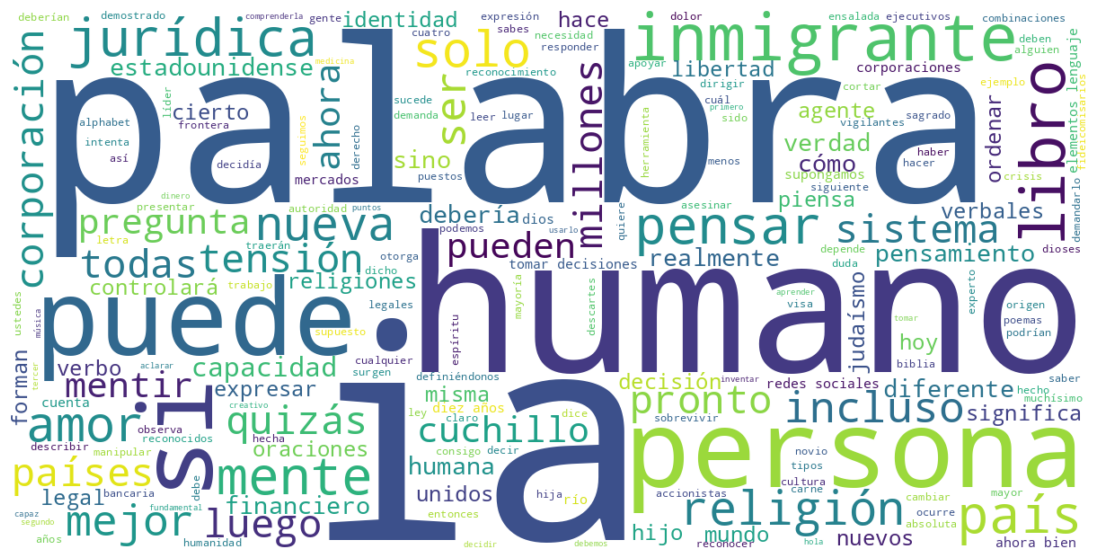

In [16]:
# Generación de la nube de palabras

from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate(texto_procesado)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

### 2.3 Usando el texto que conseguiste en el punto 1.



#### 2.3.1 Limpia y preprocesa el texto, descomponelo en oraciones, arma una matriz documento-vocabulario.


**Primero necesitamos separar nuestro discurso en oraciones. Para eso usamos sent_tokenize**

In [17]:
import nltk

nltk.download('punkt_tab')

from nltk.tokenize import sent_tokenize

# Separar el discurso en oraciones
documentos = sent_tokenize(discurso, language='spanish')

print("Cantidad de documentos:", len(documentos))

# Mostrar las primeras 5 oraciones
for i, documento in enumerate(documentos[:5], 1):
    print(f"\nDocumento {i}:")
    print(documento)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Cantidad de documentos: 129

Documento 1:
Hola a todos.

Documento 2:
Hay una pregunta que todo líder hoy debe responder sobre la IA.

Documento 3:
Pero para comprenderla, primero debemos aclarar algunos puntos sobre qué es la IA y qué puede hacer.

Documento 4:
Lo fundamental de la IA es que no es solo otra herramienta: es un agente Puede aprender, cambiar y tomar decisiones por sí misma.

Documento 5:
Un cuchillo es una herramienta.


**Repetimos la limpieza que hicimos anteriormente**

In [18]:
# Preprocesamiento de cada documento

import string
import re

documentos_procesados = []

for documento in documentos:

    # Convertir a minúsculas
    documento = documento.lower()

    # Eliminar puntuación
    documento = ''.join(
        c for c in documento
        if c not in string.punctuation
    )

    # Eliminar caracteres no deseados
    documento = re.sub(r'[^\w\s]', '', documento)

    # Separar en palabras
    palabras = documento.split()

    # Eliminar stopwords
    palabras = [
        palabra for palabra in palabras
        if palabra not in stopwords_es
    ]

    # Volver a unir las palabras
    documento = ' '.join(palabras)

    documentos_procesados.append(documento)

print("Primeros documentos procesados:\n")

for i, documento in enumerate(documentos_procesados[:5], 1):
    print(f"Documento {i}: {documento}")

Primeros documentos procesados:

Documento 1: hola
Documento 2: pregunta líder hoy debe responder ia
Documento 3: comprenderla primero debemos aclarar puntos ia puede hacer
Documento 4: fundamental ia solo herramienta agente puede aprender cambiar tomar decisiones misma
Documento 5: cuchillo herramienta


**Sabemos que el vocabulario es el conjunto de términos únicos que componen el documento, por lo que procedemos a construir el mismo basados en esta premisa para posteriormente darle un orden**

In [19]:
# Construcción del vocabulario

vocabulario = set()

for documento in documentos_procesados:
    palabras = documento.split()
    vocabulario.update(palabras)

# Ordenar el vocabulario
vocabulario = sorted(vocabulario)

print("Cantidad de términos en el vocabulario:", len(vocabulario))
print("\nPrimeros 50 términos:")
print(vocabulario[:50])

Cantidad de términos en el vocabulario: 564

Primeros 50 términos:
['abandonar', 'abierta', 'abran', 'abren', 'abrir', 'abrirán', 'absoluta', 'accionistas', 'aclarar', 'actuado', 'actuar', 'acuñaron', 'además', 'administrar', 'adquirir', 'afirmado', 'agente', 'agentes', 'ahora', 'alguien', 'alguna', 'alienta', 'allá', 'allí', 'alphabet', 'amante', 'amigables', 'amo', 'amor', 'amoroso', 'anteriores', 'apoyar', 'aprende', 'aprendemos', 'aprender', 'aprendido', 'aprendí', 'argumentan', 'argumentar', 'argumentos', 'arte', 'asesinar', 'aspecto', 'así', 'atentamente', 'aterradores', 'aunque', 'autodenomina', 'autoridad', 'años']


**Ahora si procedemos a crear nuestra matriz documento-vocabulario, para esto cada documento se convierte en un vector basado en la frecuencia de cada palabra.**

In [20]:
# Crear la matriz documento-vocabulario

import numpy as np

# Crear una matriz llena de ceros
matriz_documento_vocabulario = np.zeros(
    (len(documentos_procesados), len(vocabulario)),
    dtype=int
)

# Crear un diccionario para localizar cada término
indice_vocabulario = {
    palabra: i for i, palabra in enumerate(vocabulario)
}

# Completar la matriz con las frecuencias
for i, documento in enumerate(documentos_procesados):

    palabras = documento.split()

    for palabra in palabras:
        j = indice_vocabulario[palabra]
        matriz_documento_vocabulario[i, j] += 1

print("Tamaño de la matriz:")
print(matriz_documento_vocabulario.shape)

Tamaño de la matriz:
(129, 564)



#### 2.3.2 Determina la longitud de tu vocabulario.

**La longitud del vocabulario corresponde a la cantidad de términos únicos presentes en el conjunto de documentos luego del preprocesamiento. En este caso, el vocabulario está compuesto por 564 términos.**

In [21]:
# 2.3.2 - Longitud del vocabulario

longitud_vocabulario = len(vocabulario)

print("Longitud del vocabulario:", longitud_vocabulario)

Longitud del vocabulario: 564



#### 2.3.3. Aplica TF-IDF a tu matriz documento-vocabulario

**Primero calculamos el DF de cada término utilizando directamente matriz_documento_vocabulario que ya lo tenemos creado**

In [22]:
# 2.3.3 - Cálculo de TF-IDF

import numpy as np

# Cantidad total de documentos
N = len(documentos_procesados)

# Calcular DF: cantidad de documentos en los que aparece cada término
DF = np.sum(matriz_documento_vocabulario > 0, axis=0)

print("Cantidad de documentos:", N)
print("Cantidad de términos:", len(vocabulario))

print("\nPrimeros 10 valores de DF:")
print(DF[:10])

Cantidad de documentos: 129
Cantidad de términos: 564

Primeros 10 valores de DF:
[1 1 1 1 1 1 2 2 1 1]


**Después calculamos el IDF utilizando logaritmo en base 10**

In [23]:
# Calcular IDF utilizando logaritmo en base 10

IDF = np.log10(N / DF)

print("Primeros 10 valores de IDF:")
print(IDF[:10])

Primeros 10 valores de IDF:
[2.11058971 2.11058971 2.11058971 2.11058971 2.11058971 2.11058971
 1.80955971 1.80955971 2.11058971 2.11058971]


**Y finalmente calculamos la matriz TF-IDF**

In [24]:
# Calcular la matriz TF-IDF

matriz_tfidf = matriz_documento_vocabulario * IDF

print("Tamaño de la matriz TF-IDF:")
print(matriz_tfidf.shape)

Tamaño de la matriz TF-IDF:
(129, 564)


Se aplicó TF-IDF sobre la matriz documento-vocabulario. Este método permite ponderar los términos teniendo en cuenta tanto su frecuencia dentro de cada documento como su presencia en el conjunto de documentos.

La matriz obtenida tiene un tamaño de 129 × 564, donde las 129 filas representan los documentos del corpus y las 564 columnas representan los términos únicos del vocabulario. Cada valor de la matriz representa el peso TF-IDF de un término determinado dentro de un documento.

Los términos que aparecen en pocos documentos presentan un valor IDF mayor, mientras que los términos que aparecen en una mayor cantidad de documentos presentan un valor IDF menor. De esta manera, TF-IDF permite otorgar mayor peso a los términos más distintivos del corpus.

Explica el formato de tu matriz resultante: documentos, vocabulario, tamaño. Brinda tus conclusiones.

# Conclusiones

Agregue aquí sus conclusiones sobre este trabajo práctico. Puede ser también parte del texto que posteará en el foro.

En este trabajo se realizó el proceso completo de obtención y procesamiento de un texto utilizando técnicas de Procesamiento del Lenguaje Natural. En primer lugar, se obtuvo mediante webscraping el discurso seleccionado y posteriormente se realizó su preprocesamiento, eliminando stopwords, signos de puntuación y caracteres no deseados.

A partir del texto procesado se identificaron 129 documentos, considerando cada oración como un documento, y se obtuvo un vocabulario compuesto por 564 términos únicos. Con estos datos se construyó una matriz documento-vocabulario de 129 × 564, donde cada fila representa un documento, cada columna un término del vocabulario y cada valor indica la frecuencia con la que aparece dicho término en el documento.

Finalmente, se aplicó el método TF-IDF, obteniendo nuevamente una matriz de 129 × 564. A diferencia de la representación basada únicamente en frecuencia, TF-IDF permite ponderar los términos considerando tanto su frecuencia dentro del documento como su presencia en el conjunto de documentos, otorgando mayor importancia a los términos más distintivos.

De esta manera, el trabajo permitió aplicar los conceptos estudiados de tokenización, documentos, corpus, vocabulario, vectorización y TF-IDF, transformando un texto en una representación numérica que puede ser procesada y analizada mediante herramientas computacionales.


# Anexo, código de ejemplo del uso de wordcloud

Instalar e importar la librería

In [ ]:
# instalar wordcloud
!pip install wordcloud


In [ ]:

# Importar librerías
from wordcloud import WordCloud
import matplotlib.pyplot as plt


In [ ]:

# Texto de ejemplo
text = "Este es un texto de ejemplo para crear una nube de palabras usando word cloud. Puedes reemplazar este texto utilizando tu propio texto."

# Crear un objeto WordCloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)


Mostramos la imagen generada

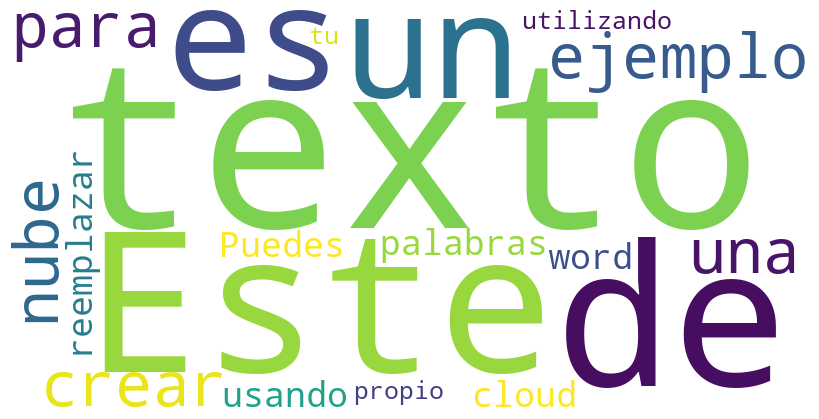

In [ ]:

# mostramos la imagen generada
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

Modificamos el ejemplo anterior agregando palabras en español que no queremos que considere para crear la nube de palabras. Estas son las stop_words



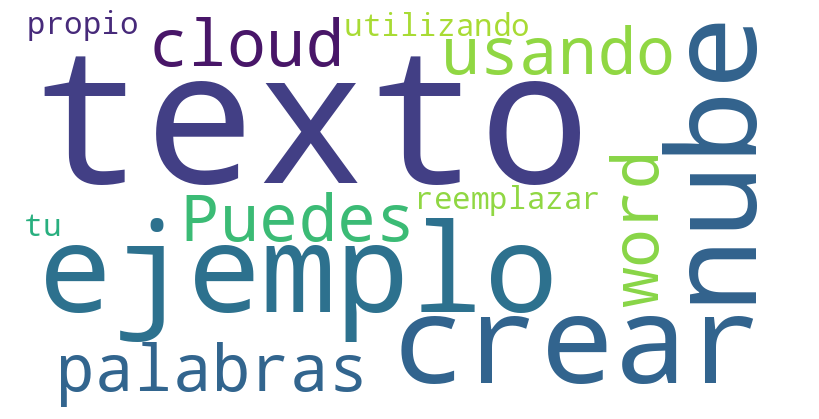

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Texto de ejemplo
text = "Este es un texto de ejemplo para crear una nube de palabras usando word cloud. Puedes reemplazar este texto utilizando tu propio texto."

# Definir stopwords en español
stopwords_es = set(STOPWORDS)
stopwords_es.update(["con", "que", "los", "para", "un", "una", "el", "la", "en", "y", "o", "de", "a", "se", "es", "al", "como", "por", "no", "su", "más", "pero", "si", "este", "esta", "eso", "esa", "todo", "todos", "todas", "cada", "cual", "cualquier", "algo", "alguna", "algún", "ningún", "ninguna", "ninguno", "otro", "otros", "otras", "sobre", "entre", "durante", "desde", "hasta", "también", "así", "mismo", "misma", "mismo", "misma", "tan", "tanto", "tanta", "muy", "poco", "poca", "poco", "nada", "solo", "sola", "solo", "sola", "siempre", "nunca", "jamás", "casi", "aproximadamente", "cerca", "lejos", "antes", "después", "ahora", "hoy", "ayer", "mañana", "luego", "mientras", "mientras tanto", "después de", "antes de", "durante", "sin", "aunque", "a pesar de", "debido a", "gracias a", "por qué", "cómo", "dónde", "cuándo", "quién", "qué", "cuál"])

# Crear un objeto WordCloud con stopwords en español
wordcloud = WordCloud(width=800, height=400, background_color="white", stopwords=stopwords_es).generate(text)

# Mostramos la imagen generada
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()
